Analysation of the data coming from the simulator.

In [9]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

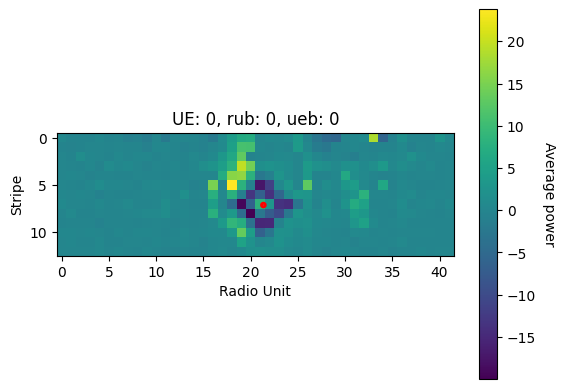

In [ ]:
ue_ds = xr.load_dataset("configurations/ue_locations_5681.nc")

for i in range(1):
    user = ue_ds.where(ue_ds["user_id"] == i, drop=True)
    x = float(user["x"])
    y = float(user["y"])
    z = float(user["z"])

    # Read in the data for UEx
    df = pd.read_pickle(f"simulations/flickering_data_{i}.pkl")

    # Make a plot for every UE. The plot is a heatmap with the data for every stripe on the y-axis and the data for every
    # RU on the x-axis.

    for rub_id in df["ru_beam_id"].unique():
        for ueb_id in df["ue_beam_id"].unique():
            # Get the data for this specific stripe.
            beam_data = df.loc[(df["ru_beam_id"] == rub_id) & (df["ue_beam_id"] == ueb_id)]
            data = beam_data.pivot(index="stripe_id", columns="ru_id", values="sndr_cu")
        
            fig, ax = plt.subplots()
            im = ax.imshow(data)
            circle = Circle(((y-2.5) * 2, (x-2.0) * 2), radius=0.2, edgecolor='red', facecolor='none', linewidth=2)
            ax.add_patch(circle)

            # Create colorbar
            cbar = ax.figure.colorbar(im, ax=ax)
            cbar.ax.set_ylabel("Average power", rotation=-90, va="bottom")

            ax.set_title(f"UE: {i}, rub: {rub_id}, ueb: {ueb_id}")
            ax.set_ylabel("Stripe")
            ax.set_xlabel("Radio Unit")